In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import datetime

# Coleoptera list

In [2]:
Coleoptera_list = pd.read_csv('./raw/0005486-250415084134356.csv', sep = '\t')

# target50 species

In [3]:
target_species50_1 = pd.read_csv('./raw/0005424-250415084134356.csv', sep = '\t')
target_species50_2 = pd.read_csv('./raw/0005461-250415084134356.csv', sep = '\t')

target_species50 = pd.concat([target_species50_1, target_species50_2]).reset_index(drop = True)

/tmp/ipykernel_2732529/2161118802.py:1: DtypeWarning: Columns (10,39,45,46) have mixed types. Specify dtype option on import or set low_memory=False.
  target_species50_1 = pd.read_csv('./raw/0005424-250415084134356.csv', sep = '\t')


# 30 families of all beetles in 1960 survey

In [4]:
df_gbif_family = pd.read_csv('./raw/0009028-250415084134356.csv', sep = '\t')

/tmp/ipykernel_2732529/1468485342.py:1: DtypeWarning: Columns (14,16,17,38,39,40,41,43,44,45,46,48) have mixed types. Specify dtype option on import or set low_memory=False.
  df_gbif_family = pd.read_csv('./raw/0009028-250415084134356.csv', sep = '\t')


# monitoring 1000

## SIN03

In [5]:
df_splist = pd.read_csv('./raw/SIN03/SpListGB-2021-ver2022j.csv', encoding = 'shift_jis')
df_plotlist = pd.read_csv('./raw/SIN03/PlotListGB-2021-ver2023j.csv', encoding = 'shift_jis', skiprows = [0, 73, 72, 71, 70, 69, 68, 67, 66])

In [6]:
record_list = []
for file in os.listdir('./raw/SIN03/PitfallBeetle-2004-2021-ver2023j/'):
    if file.endswith('.csv'):
        df_gbrecord = pd.read_csv(f'./raw/SIN03/PitfallBeetle-2004-2021-ver2023j/{file}', encoding = 'shift_jis', usecols = ['plot', 'date', 'tax_no', 'gbif', 'gen', 'sp', 'abund', 'fam'])
        
        # Valid scientific name
        df_gbrecord = df_gbrecord[~pd.isna(df_gbrecord.tax_no)].reset_index(drop = True)
        df_gbrecord = df_gbrecord[['99' not in str(tax_no) for tax_no in df_gbrecord.tax_no]].reset_index(drop = True)
        
        # Records not in gbif
        df_gbrecord = df_gbrecord[pd.isna(df_gbrecord.gbif)].reset_index(drop = True)
        
        record_list.append(df_gbrecord)
df_record = pd.concat(record_list).reset_index(drop = True)

/tmp/ipykernel_2732529/3517761481.py:4: DtypeWarning: Columns (42) have mixed types. Specify dtype option on import or set low_memory=False.
  df_gbrecord = pd.read_csv(f'./raw/SIN03/PitfallBeetle-2004-2021-ver2023j/{file}', encoding = 'shift_jis', usecols = ['plot', 'date', 'tax_no', 'gbif', 'gen', 'sp', 'abund', 'fam'])


In [7]:
df_record['species'] = df_record.apply(lambda x: f"{x['gen']} {x['sp']}", axis = 1)
df_record['year'] = [i[0:4] for i in df_record.date.astype('int64').astype('str')]
df_record['month'] = [i[4:6] for i in df_record.date.astype('int64').astype('str')]
df_record['day'] = [i[6:8] for i in df_record.date.astype('int64').astype('str')]

In [8]:
# index of every record aligned to the PLOT dataframe
i_plot = [np.where((df_plotlist['プロットID']) == plots)[0][0] for plots in df_record['plot']]
df_record['lat'] = df_plotlist['経度c'][i_plot].reset_index(drop = True)
df_record['lon'] = df_plotlist['緯度c'][i_plot].reset_index(drop = True)

In [9]:
# filter the records whose family belongs to the 30 family
df_record = df_record[df_record.fam.isin(set(df_gbif_family.family))]

### 以下處理有在monitoring1000但是沒有在gbif中的學名

In [10]:
len(set(df_record.species))

310

In [11]:
len(set(df_record.species) - set(df_gbif_family.species))

73

In [12]:
len(set(df_record.species) - (set(df_record.species) - set(df_gbif_family.species)))

237

### 這些是monitoring1000的名字要改回gbif的名字

In [13]:
change_name = {'Allecula fuliginosa': 'Upinella jingfui', 
               'Apterodela ovipennis': 'Cylindera ovipennis', 
               'Archaeoglenes orientalis': 'Archaeoglenes fujikawai', 
               'Badister nakayamai': 'Badister marginellus', 
               'Carabus tosanus': 'Carabus dehaanii', 
               'Eucolpodes aurelium': 'Eucolpodes aurelius', 
               'Eucolpodes japonicum': 'Eucolpodes japonicus', 
               'Holotrichia picea': 'Pedinotrichia picea', 
               'Limodromus subovatus': 'Platynus subovatus', 
               'Nipponagonum amphinomum': 'Nipponagonum amphinomus', 
               'Onthophagus itoi': 'Parascatonomus itoi', 
               'Onthophagus murasakianus': 'Parascatonomus murasakianus', 
               'Onthophagus nitidus': 'Parascatonomus nitidus', 
               'Onthophagus shibatai': 'Parascatonomus shibatai', 
               'Philonthus kobensis': 'Bisnius kobensis', 
               'Phosphuga atrata': 'Silpha atrata', 
               'Pinophilus lewisius': 'Phinopilus lewisius', 
               'Pterostichus straneoi': 'Pterostichus straneoi', 
               'Trechus vicarius': 'Epaphius vicarius', 
               'Trox mutsuensis': 'Trox mutsuensis', 
               'Xestagonum xestum': 'Xestagonum xestus', 
               'Agonum kitanoi': 'Agonum bicolor'}

### 這些是monitoring1000的名字，GBIF上有這個學名的記錄，但不是有效名，因此這些記錄只被記到屬而已

In [14]:
monitoring1000_only = ['Anthrenus tanakai', 'Basanus erotyloides', 'Derispia japonicola', 'Derispia maculipennis', 'Eucrossoscelis michioi', 'Glischrochilus subcylindricus', 
'Gonocephalum japanum', 'Isorhipis foveata', 'Laena hiranoi', 'Lagria rufipennis', 'Luprops cribrifrons', 'Megalopaederus lewisi', 
'Misolampidius okumurai', 'Misolampidius rugipennis', 'Mycetina amabilis', 'Neopallodes inermis', 'Orchesia imitans', 'Paramisolampidius kagoshimensis', 
'Physoronia explanata', 'Physoronia japonica', 'Plagiosterna japonica', 'Plesiophthalmus nigrocyaneus', 'Pseudopyrochroa laticollis', 'Pterostichus habui', 
'Scaphidema pictipenne', 'Stenochinus bacillus', 'Strongylium brevicorne', 'Syneta adamsi', 'Uloma latimanus', 'Uloma marseuli', 'Uncifer pectoralis']

### 這些是monitoring1000的名字，但是GBIF上完全沒有這個名字的記錄

In [15]:
monitoring_nogbif = ['Clamoris canalicollis', 'Microplinthus variegatus']

### 把monitoring1000中，gbif有的學名整理出來，gbif不認的學名就先放著

In [16]:
df_record_filter = df_record[df_record.species.isin(set(df_gbif_family.species) | set(change_name.keys()))].reset_index(drop = True)

In [17]:
df_record_filter['species_changed'] = [change_name.get(sp, sp) for sp in df_record_filter.species]

In [18]:
df_record_filter = df_record_filter[['species_changed', 'year', 'month', 'day', 'lat', 'lon']].rename(columns = {
    'species_changed': 'species', 
    'lat': 'decimalLatitude', 
    'lon': 'decimalLongitude'
})

In [19]:
df_gbif_filter = df_gbif_family[['species', 'decimalLatitude', 'decimalLongitude', 'day', 'month', 'year']].dropna().reset_index(drop = True)

In [20]:
df_merged = pd.concat([df_record_filter, df_gbif_filter], ignore_index=True).reset_index(drop = True)

In [21]:
df_merged.year = df_merged.year.astype('int')
df_merged.month = df_merged.month.astype('int')
df_merged.day = df_merged.day.astype('int')

## KOZ07

In [22]:
folder_list = ['mot-az_4b', 'mot-az_4c1', 'mot-az_4c2', 'mot-az_4d']

In [23]:
df_dict = dict()
for folder in folder_list:
    for file in os.listdir(os.path.join('raw', 'KOZ07', folder)):
        if file.endswith('.xlsx'):
            file_path = os.path.join('raw', 'KOZ07', folder, file)
            df = pd.read_excel(file_path, engine = 'openpyxl', sheet_name = None, header=None)
        elif file.endswith('.xls'):
            file_path = os.path.join('raw', 'KOZ07', folder, file)
            df = pd.read_excel(file_path, engine = 'xlrd', sheet_name = None, header = None)
        else:
            continue
        # check every sheet name
        for key in df:
            if '科' in df[key].values:
                df_dict[f'{folder}-{file}-{key}'] = df[key]
            else:
                pass

In [24]:
all_records = []
for info in df_dict:
    data = df_dict[info]
    temp_df = pd.DataFrame(data)

    # 提取所需資訊
    set_up_date = temp_df[temp_df[0] == 'トラップ設置日'].iloc[0, 1]
    retrieval_date = temp_df[temp_df[0] == 'トラップ回収日'].iloc[0, 1]
    latitude = temp_df[temp_df[0] == '北緯（°）'].iloc[0, 1]
    longitude = temp_df[temp_df[0] == '東経（°）'].iloc[0, 1]

    # 確保日期為 YYYY-MM-DD 格式
    if isinstance(set_up_date, datetime.datetime):
        set_up_date = pd.to_datetime(set_up_date).strftime('%Y-%m-%d')
    else:
        print(set_up_date)
    if isinstance(retrieval_date, datetime.datetime):
        retrieval_date = pd.to_datetime(retrieval_date).strftime('%Y-%m-%d')
    else:
        print(retrieval_date)

    # 定位物種資料起始點
    header_idx = temp_df[temp_df.iloc[:, 0] == '科'].index[0]
    species_data = temp_df.iloc[header_idx+1:, :4].dropna(how='all')
    species_data.columns = ['Family', 'Japanese_Name', 'Scientific_Name', 'Count']

    # 加入各項記錄
    for _, row in species_data.iterrows():
        record = {
            'Set_Up_Date': set_up_date,
            'Retrieval_Date': retrieval_date,
            'Latitude': latitude,
            'Longitude': longitude,
            'Family': row['Family'],
            'Japanese_Name': row['Japanese_Name'],
            'Scientific_Name': row['Scientific_Name'],
            'Count': row['Count']
        }
        all_records.append(record)
        
    print(f'{info}: {len(species_data)}')
# 產生最終 DataFrame
final_df = pd.DataFrame(all_records)

mot-az_4b-mot-az_4b_beetle_2009.xls-７月: 6
mot-az_4b-mot-az_4b_beetle_2009.xls-８月: 1
mot-az_4b-mot-az_4b_beetle_2010.xlsx-サナギ粉1回目: 9
mot-az_4b-mot-az_4b_beetle_2010.xlsx-すし粉1回目: 6
mot-az_4b-mot-az_4b_beetle_2010.xlsx-1回目合計: 9
mot-az_4b-mot-az_4b_beetle_2010.xlsx-サナギ粉2回目: 6
mot-az_4b-mot-az_4b_beetle_2010.xlsx-すし粉2回目: 4
mot-az_4b-mot-az_4b_beetle_2010.xlsx-2回目合計: 7
mot-az_4b-mot-az_4b_beetle_2011.xls-すし粉: 0
mot-az_4b-mot-az_4b_beetle_2011.xls-サナギ粉: 7
mot-az_4b-mot-az_4b_beetle_2011.xls-合計: 7
mot-az_4b-mot-az_4b_beetle_2012.xls-すし粉: 3
mot-az_4b-mot-az_4b_beetle_2012.xls-サナギ粉 : 6
mot-az_4b-mot-az_4b_beetle_2012.xls-合計: 6
mot-az_4b-mot-az_4b_beetle_2013.xlsx-すし粉: 6
mot-az_4b-mot-az_4b_beetle_2013.xlsx-サナギ粉: 7
mot-az_4b-mot-az_4b_beetle_2013.xlsx-合計: 8
mot-az_4b-mot-az_4b_beetle_2014.xls-千蛇ヶ池南方風衝地すし粉・サナギ粉合計: 6
mot-az_4b-mot-az_4b_beetle_2015.xlsx-千蛇ヶ池南方風衝地すし粉・サナギ粉合計: 7
mot-az_4b-mot-az_4b_beetle_2016.xls-千蛇ヶ池南方風衝地すし粉・サナギ粉合計: 4
mot-az_4b-mot-az_4b_beetle_2017.xls-4Bi: 6
mot-az_4b-mot-az_4b_be

In [25]:
final_df = final_df.replace('20208/3', '2020-08-03')

In [26]:
final_df = final_df[~pd.isna(final_df.Scientific_Name)].reset_index(drop = True)

In [27]:
final_df = final_df[~final_df.Scientific_Name.str.contains('sp\.')].reset_index(drop = True)

In [28]:
final_df['species'] = final_df.apply(lambda x: " ".join(x['Scientific_Name'].split()[:2]), axis = 1)

In [29]:
final_df

,Set_Up_Date,Retrieval_Date,Latitude,Longitude,Family,Japanese_Name,Scientific_Name,Count,species
0,2009-07-23,2009-07-24,36.1547,136.7663,オサムシ科,キタクロナガオサムシ,Carabus arboreus Lewis 1882,6.0,Carabus arboreus
1,2009-07-23,2009-07-24,36.1547,136.7663,オサムシ科,チビマルクビゴミムシ,Nippononebria pusilla (Ueno 1955),7.0,Nippononebria pusilla
2,2009-07-23,2009-07-24,36.1547,136.7663,オサムシ科,コイケミズギワゴミムシ,"Bembidion koikei Habu & Baba, 1960",11.0,Bembidion koikei
3,2009-07-23,2009-07-24,36.1547,136.7663,オサムシ科,キタノヒラタゴミムシ,Agonum kitanoi Habu 1956,2.0,Agonum kitanoi
4,2009-07-23,2009-07-24,36.1547,136.7663,オサムシ科,ツヤモリヒラタゴミムシ,Xestagonum xestum (Bstes 1883),4.0,Xestagonum xestum
...,...,...,...,...,...,...,...,...,...
448,2023-07-30,2023-07-31,36.1350,136.7735,オサムシ科,コイケミズギワゴミムシ,"Bembidion koikei Habu & Baba, 1960",1.0,Bembidion koikei
449,2023-07-30,2023-07-31,36.1350,136.7735,オサムシ科,オンタケヒメヒラタゴミムシ,"Agonum charillus (Bates, 1883)",13.0,Agonum charillus
450,2023-07-30,2023-07-31,36.1350,136.7735,オサムシ科,ホシナガゴミムシ,"Pterostichus oblongopunctatus Fabricius, 1787",5.0,Pterostichus oblongopunctatus
451,2023-07-30,2023-07-31,36.1350,136.7735,ハネカクシ科,ナカアカヒゲブトハネカクシ,Aleochara curtula (Goeze 1777),8.0,Aleochara curtula


In [30]:
# 先確認Count為數值
final_df['Count'] = pd.to_numeric(final_df['Count'], errors='coerce')

# 根據指定條件分組後，保留 Count 最大的紀錄
cleaned_df = final_df.loc[
    final_df.groupby(['Set_Up_Date', 'Retrieval_Date', 'Latitude', 'Longitude', 'species'])['Count'].idxmax()
].reset_index(drop=True)

cleaned_df

,Set_Up_Date,Retrieval_Date,Latitude,Longitude,Family,Japanese_Name,Scientific_Name,Count,species
0,2009-07-23,2009-07-24,36.1350,136.7735,オサムシ科,オンタケヒメヒラタゴミムシ,"Agonum charillus (Bates, 1883)",119.0,Agonum charillus
1,2009-07-23,2009-07-24,36.1350,136.7735,オサムシ科,コイケミズギワゴミムシ,"Bembidion koikei Habu & Baba, 1960",112.0,Bembidion koikei
2,2009-07-23,2009-07-24,36.1350,136.7735,シデムシ科,ビロウドヒラタシデムシ,Oiceoptoma thoracicum (Linnaeus 1758),4.0,Oiceoptoma thoracicum
3,2009-07-23,2009-07-24,36.1350,136.7735,オサムシ科,ホシナガゴミムシ,Pterostichus oblongopunctatus Fabricius 1787,4.0,Pterostichus oblongopunctatus
4,2009-07-23,2009-07-24,36.1350,136.7735,オサムシ科,オンタケナガチビゴミムシ,Trechiama lewisi (Jeannel 1924),1.0,Trechiama lewisi
...,...,...,...,...,...,...,...,...,...
301,2023-07-30,2023-07-31,36.1547,136.7663,オサムシ科,ミヤマゴモクムシ,"Harpalus solitaris Dejean, 1829",1.0,Harpalus solitaris
302,2023-07-30,2023-07-31,36.1547,136.7663,コメツキムシ科,ミヤマヒサゴコメツキ,"Homotechnes motschulskyi (Fleutiaux, 1902)",1.0,Homotechnes motschulskyi
303,2023-07-30,2023-07-31,36.1547,136.7663,ハネカクシ科,ハクサンドウガネナガハネカクシ,"Platydomene hakusana Y.Watanabe, 2008",4.0,Platydomene hakusana
304,2023-07-30,2023-07-31,36.1547,136.7663,ハネカクシ科,ハクサンサビイロモンキハネカクシ,"Protocypus hakusanus (Naomi, 1992)",1.0,Protocypus hakusanus


In [31]:
cleaned_df['species_gbifname'] = cleaned_df.apply(lambda x: change_name.get(x['species'], x['species']), axis = 1)

In [32]:
df_KOZ07_filter = cleaned_df[cleaned_df.species_gbifname.isin(set(df_gbif_family.species) | set(change_name.keys()))].reset_index(drop = True)

In [33]:
df_KOZ07_filter

,Set_Up_Date,Retrieval_Date,Latitude,Longitude,Family,Japanese_Name,Scientific_Name,Count,species,species_gbifname
0,2009-07-23,2009-07-24,36.1350,136.7735,オサムシ科,オンタケヒメヒラタゴミムシ,"Agonum charillus (Bates, 1883)",119.0,Agonum charillus,Agonum charillus
1,2009-07-23,2009-07-24,36.1350,136.7735,オサムシ科,コイケミズギワゴミムシ,"Bembidion koikei Habu & Baba, 1960",112.0,Bembidion koikei,Bembidion koikei
2,2009-07-23,2009-07-24,36.1350,136.7735,シデムシ科,ビロウドヒラタシデムシ,Oiceoptoma thoracicum (Linnaeus 1758),4.0,Oiceoptoma thoracicum,Oiceoptoma thoracicum
3,2009-07-23,2009-07-24,36.1350,136.7735,オサムシ科,ホシナガゴミムシ,Pterostichus oblongopunctatus Fabricius 1787,4.0,Pterostichus oblongopunctatus,Pterostichus oblongopunctatus
4,2009-07-23,2009-07-24,36.1350,136.7735,オサムシ科,オンタケナガチビゴミムシ,Trechiama lewisi (Jeannel 1924),1.0,Trechiama lewisi,Trechiama lewisi
...,...,...,...,...,...,...,...,...,...,...
291,2023-07-30,2023-07-31,36.1547,136.7663,オサムシ科,コイケミズギワゴミムシ,"Bembidion koikei Habu & Baba, 1960",2.0,Bembidion koikei,Bembidion koikei
292,2023-07-30,2023-07-31,36.1547,136.7663,オサムシ科,コクロナガオサムシ,"Carabus arboreus Lewis, 1882",2.0,Carabus arboreus,Carabus arboreus
293,2023-07-30,2023-07-31,36.1547,136.7663,オサムシ科,ミヤマゴモクムシ,"Harpalus solitaris Dejean, 1829",1.0,Harpalus solitaris,Harpalus solitaris
294,2023-07-30,2023-07-31,36.1547,136.7663,コメツキムシ科,ミヤマヒサゴコメツキ,"Homotechnes motschulskyi (Fleutiaux, 1902)",1.0,Homotechnes motschulskyi,Homotechnes motschulskyi


In [34]:
df_KOZ07_filter = df_KOZ07_filter[['species_gbifname', 'Retrieval_Date', 'Latitude', 'Longitude']].rename(columns = {
    'species_gbifname': 'species', 
    'Latitude': 'decimalLatitude', 
    'Longitude': 'decimalLongitude'
})

In [35]:
df_KOZ07_filter['year'] = df_KOZ07_filter.apply(lambda x: int(x['Retrieval_Date'].split('-')[0]), axis = 1)
df_KOZ07_filter['month'] = df_KOZ07_filter.apply(lambda x: int(x['Retrieval_Date'].split('-')[1]), axis = 1)
df_KOZ07_filter['day'] = df_KOZ07_filter.apply(lambda x: int(x['Retrieval_Date'].split('-')[2]), axis = 1)

df_KOZ07_filter = df_KOZ07_filter.drop('Retrieval_Date', axis = 1)

In [36]:
df_merged = pd.concat([df_merged, df_KOZ07_filter], ignore_index=True).reset_index(drop = True)

In [37]:
df_merged.to_csv('./raw/gbif_1000monitoring_merged.csv', sep = '\t', index = None)

# Check how many occurrence points of Jonen 1960 species

In [38]:
species_list_Jonen1960 = ['Ptomascopus_morio', 'Aleochara_curtula', 'Nicrophorus_tenuipes', 'Nicrophorus_vespilloides', 'Margarinotus_niponicus', 'Nicrophorus_quadripunctatus', 'Philonthus_oberti', 'Silpha_longicornis', 'Catops_sparcepunctatus', 'Catops_hilleri', 'Nicrophorus_maculifrons', 'Nicrophorus_concolor', 'Oiceoptoma_thoracicum', 'Nicrophorus_investigator', 'Cercyon_ustus', 'Sciodrepoides_fumatus', 'Pterostichus_subovatus', 'Catopodes_fuscifrons', 'Onthophagus_ater', 'Pterostichus_abaciformis', 'Oiceoptoma_subrufum', 'Synuchus_melantho', 'Onthophagus_atripennis', 'Pterostichus_janoi', 'Tachinus_trifidus', 'Pterostichus_asymmetricus', 'Pterostichus_nakanei', 'Phelotrupes_laevistriatus', 'Synuchus_takeuchii', 'Nicrophorus_montivagus', 'Synuchus_arcuaticollis', 'Synuchus_cycloderus', 'Pterostichus_uenoi', 'Bisnius_kamimurai', 'Pterostichus_polygenus', 'Saprinus_niponicus', 'Philonthus_discrepens', 'Trox_opacotuberculatus', 'Pterostichus_microcephalus', 'Catops_jonensis', 'Synuchus_nitidus', 'Platydracus_brevicornis', 'Carabus_arboreus', 'Pterostichus_yoritomus', 'Mesocatops_japonicus', 'Brachinus_nigridorsis', 'Bembidion_koikei', 'Ipelates_striatipennis', 'Ontholestes_gracilis', 'Catops_nurukawae', 'Cercyon_jonensis', 'Prionochaeta_harmandi', 'Tachinus_japonicus', 'Myas_cuprescens', 'Gonocephalum_japanum', 'Bisnius_kobensis', 'Anisolinus_picticornis', 'Platydracus_circumcinctus', 'Synuchus_dulcigradus', 'Xestagonum_xestus', 'Protocypus_dorsalis', 'Quedius_abnormalis', 'Oiceoptoma_nigropunctatum', 'Nebria_sadona', 'Pterostichus_cristatoides', 'Protocypus_scutiger', 'Epaphius_vicarius', 'Cercyon_olibrus', 'Ptomaphagus_sibiricus', 'Synuchus_fukuharai', 'Anotylus_antennarius', 'Philonthus_japonicus', 'Xestagonum_xestus', 'Philonthus_nakanei', 'Glyptotrox_mutsuensis', 'Synuchus_crocatus', 'Hesperus_tiro', 'Carabus_procerulus', 'Pristosia_aeneola', 'Catops_angustitarsis', 'Pterostichus_japonicus', 'Bisnius_jonenensis', 'Sciodrepoides_alpestris', 'Nodynus_leucofasciatus', 'Quedius_yasuhikoi', 'Saprinus_planiusculus', 'Acrossus_igai', 'Anotylus_vicinus', 'Stomis_prognathus', 'Harpalus_griseus', 'Lycoperdina_castaneipennis', 'Hylobius_abietis', 'Margarinotus_balloui', 'Caccobius_jessoensis', 'Synuchus_agonus', 'Cercyon_shinanensis', 'Poecilus_samurai', 'Margarinotus_boleti', 'Proteinus_crassicornis', 'Philonthus_tardus', 'Quedius_adustus', 'Peltocercyon_subopacipennis', 'Meloe_menoko', 'Meloe_coarctatus', 'Anisolinus_elegans', 'Platydracus_vicarius', 'Negreum_mutator', 'Paederus_wadai', 'Parascatonomus_nitidus', 'Onthophagus_fodiens', 'Carabus_blaptoides', 'Thanatophilus_rugosus', 'Agrilinus_hasegawai', 'Necrophila_brunnicollis', 'Philonthus_caeruleipennis', 'Pterostichus_karasawai', 'Trephionus_nikkoensis', 'Trichotichnus_congruus', 'Harpalus_pastor', 'Megarthrus_shibatai', 'Tachinus_obesus', 'Chrysolina_aurichalcea', 'Agoliinus_shibatai', 'Nippononebria_pusilla', 'Brachinus_stenoderus', 'Pachysternum_haemorrhoum', 'Othius_rosti', 'Philonthus_addendus', 'Philonthus_virgatus', 'Platydracus_inornatus', 'Eucibdelus_japonicus', 'Tachinus_mimulus', 'Aleochara_parens', 'Onthophilus_kamiyai', 'Calosoma_maximowiczi', 'Carabus_harmandi', 'Nebria_nakanei', 'Synuchus_atricolor', 'Amara_chalcites', 'Apteroloma_discicolle', 'Nicrophorus_japonicus', 'Philonthus_longicornis', 'Tachinus_gelidus', 'Nothomyllocerus_griseus', 'Shirahoshizo_pini', 'Metahylobius_jonensis', 'Micronemadus_pusillimus', 'Sciodrepoides_hidakai', 'Gabrius_nigritulus', 'Quedius_annectens', 'Tachinus_elongatus', 'Pseudalosterna_misella', 'Nipponalophus_nutakkanus', 'Glyptotrox_mandli', 'Caccobius_suzukii', 'Brachiaphodius_eccoptus', 'Acrossus_japonicus', 'Melanotus_legatus', 'Ectinus_dahuricus', 'Carabus_albrechti', 'Leistus_subaeneus', 'Dolichus_halensis', 'Trichotichnus_imafukui', 'Cercyon_rubicundus', 'Dermestes_tessellatocollis', 'Philonthus_spinipes', 'Philonthus_subvarians', 'Creophilus_maxillosus', 'Agelosus_carinatus', 'Parabolitobius_prolongatus', 'Galeruca_dahlii', 'Gallerucida_bifasciata', 'Hylobius_montivagus', 'Hister_japonicus', 'Pseudcolenis_hilleri', 'Catops_japonensis', 'Panelus_parvulus', 'Maladera_kamiyai', 'Dalopius_exilis', 'Hemicarabus_tuberculosus', 'Carabus_insulicola', 'Trechus_ephippiatus', 'Pterostichus_haptoderoides', 'Agonum_bicolor', 'Colpodes_sylphis', 'Harpalus_tridens', 'Harpalus_discrepans', 'Chlaenius_inops', 'Cercyon_costulipennis', 'Prostomis_latoris', 'Omosita_discoidea', 'Lycoperdina_dux', 'Uloma_bonzica', 'Meloe_violaceus', 'Camioleum_loripes', 'Pteroloma_koebelei', 'Eusilpha_japonica', 'Megarthrus_hemipterus', 'Rugilus_longipennis', 'Panscopaeus_lithocharoides', 'Platydomene_nobilis', 'Bisnius_puella', 'Ocypus_japonicus', 'Quedius_viduus', 'Tachinus_nigriceps', 'Pidonia_aegrota', 'Pidonia_puziloi', 'Japanostrangalia_dentatipennis', 'Mesechthistatus_furciferus', 'Nupserha_sericans', 'Lema_cirsicola', 'Linaeidea_aenea', 'Oomorphoides_cupreatus', 'Stenoluperus_nipponensis', 'Tropideres_roelofsi', 'Deporaus_mannerheimi', 'Euops_splendida', 'Phyllobius_galloisi', 'Byrsopages_kiso', 'Protacallinus_uenoi', 'Pissodes_obscurus', 'Hylobius_laeviventris', 'Hylobius_adachii', 'Niphades_variegatus', 'Hyposipalus_gigas', 'Phloeophagosoma_curvirostre', 'Dryocoetes_hectographus', 'Merohister_jekeli', 'Leiodes_alpicola', 'Catops_spinipennis', 'Dorcus_striatipennis', 'Agrilinus_madara', 'Maladera_orientalis', 'Paraserica_grisea', 'Sericania_hidana', 'Sericania_mimica', 'Byrrhus_fasciatus', 'Agrypnus_binodulus', 'Liotrichus_hypocrita', 'Cardiophorus_pinguis', 'Limoniscus_niponensis', 'Hemicrepidius_secessus']

In [45]:
df_target_species = df_merged[df_merged.species.isin([' '.join(sp.split('_')) for sp in species_list_Jonen1960])].reset_index(drop=True)
len(df_target_species)

84532

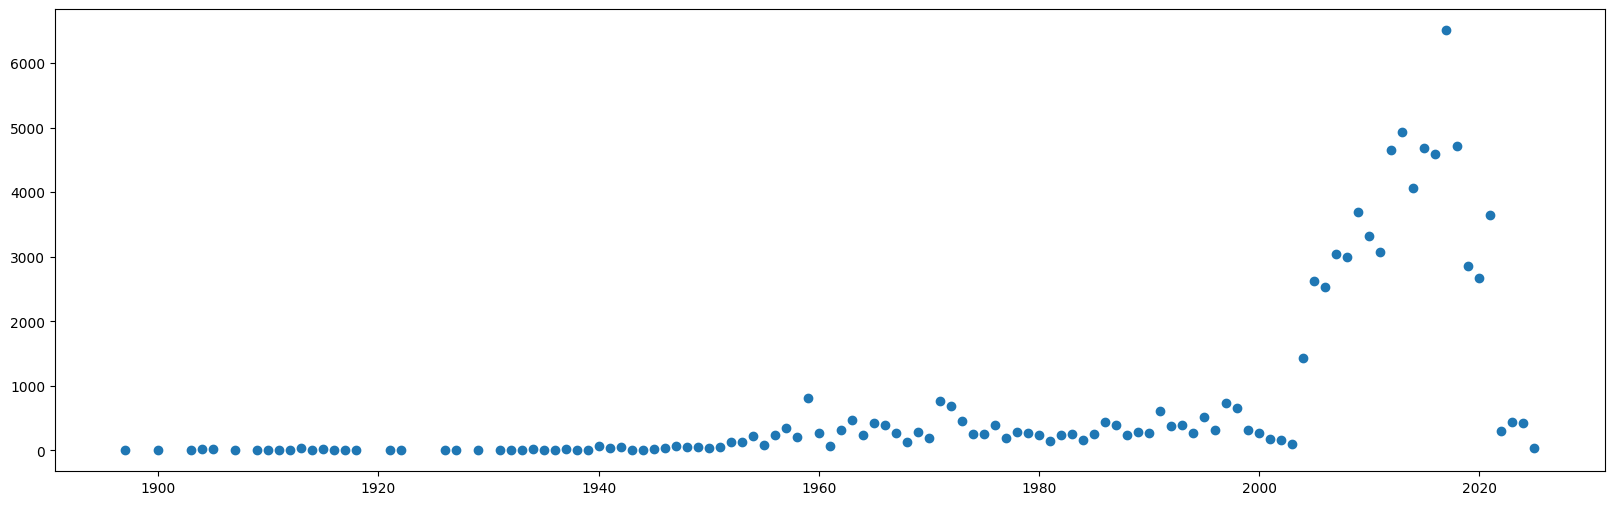

In [46]:
fig, ax = plt.subplots(figsize = (20, 6))
ax.scatter(y = df_target_species.groupby('year').count().species, x = sorted(pd.unique(df_target_species.year)))

In [48]:
df_target_species = df_target_species[(df_target_species.year <= 2021) & (df_target_species.year >= 2002)].reset_index(drop = True)
len(df_target_species)

66324

In [61]:
df_target_species[df_target_species.species == 'Ptomascopus morio']

,species,year,month,day,decimalLatitude,decimalLongitude
40674,Ptomascopus morio,2002,4,26,38.109726,128.464155
40771,Ptomascopus morio,2012,7,13,37.179111,129.074194
40786,Ptomascopus morio,2013,7,30,35.511917,126.613500
40792,Ptomascopus morio,2013,7,24,35.690389,126.665917
40793,Ptomascopus morio,2013,7,24,35.651528,126.547611
...,...,...,...,...,...,...
65639,Ptomascopus morio,2018,7,26,35.616150,129.173660
65650,Ptomascopus morio,2018,7,26,35.616150,129.173660
65861,Ptomascopus morio,2018,7,26,35.616150,129.173660
65863,Ptomascopus morio,2018,7,26,35.616150,129.173660


In [65]:
df_ = pd.read_csv('/home/klok0126/DeepSDM_Japan/workspace/species_data/occurrence_data/species_occurrence_filter.csv')
df_[df_.species == 'Ptomascopus_morio']

,species,year,month,day,decimalLatitude,decimalLongitude,date,daysincebegin
838,Ptomascopus_morio,2002,4,26,38.109726,128.464155,2002-4-26,115
2173,Ptomascopus_morio,2012,7,13,37.179111,129.074194,2012-7-13,3846
2357,Ptomascopus_morio,2013,7,30,35.511917,126.613500,2013-7-30,4228
2421,Ptomascopus_morio,2013,7,24,35.690389,126.665917,2013-7-24,4222
2428,Ptomascopus_morio,2013,7,24,35.651528,126.547611,2013-7-24,4222
...,...,...,...,...,...,...,...,...
132032,Ptomascopus_morio,2018,7,26,35.616150,129.173660,2018-7-26,6050
132054,Ptomascopus_morio,2018,7,26,35.616150,129.173660,2018-7-26,6050
133491,Ptomascopus_morio,2018,7,26,35.616150,129.173660,2018-7-26,6050
133493,Ptomascopus_morio,2018,7,26,35.616150,129.173660,2018-7-26,6050


In [81]:
len(species_list_Jonen1960)

242

In [69]:
import h5py
import rasterio

In [77]:
files = os.listdir('./workspace/raster_data/species_occurrence/')

In [81]:
for file in files:
    counts = 0
    with h5py.File(f'./workspace/raster_data/species_occurrence/{file}', 'r') as h5f:
        dataset_names = h5f.keys()
        for dn in dataset_names:
            counts += (h5f[dn][:] == 1).sum()
    print(f'{file}: {counts}')

Agelosus_carinatus.h5: 135
Agonum_bicolor.h5: 28
Agrilinus_hasegawai.h5: 9
Agrypnus_binodulus.h5: 253
Aleochara_curtula.h5: 27
Aleochara_parens.h5: 12
Amara_chalcites.h5: 76
Anisolinus_elegans.h5: 42
Anotylus_antennarius.h5: 3
Anotylus_vicinus.h5: 86
Bembidion_koikei.h5: 79
Bisnius_kobensis.h5: 47
Brachiaphodius_eccoptus.h5: 68
Brachinus_stenoderus.h5: 15
Byrrhus_fasciatus.h5: 6
Caccobius_jessoensis.h5: 101
Caccobius_suzukii.h5: 40
Calosoma_maximowiczi.h5: 36
Camioleum_loripes.h5: 37
Carabus_albrechti.h5: 470
Carabus_arboreus.h5: 227
Carabus_blaptoides.h5: 368
Carabus_harmandi.h5: 3
Carabus_insulicola.h5: 341
Carabus_procerulus.h5: 205
Cardiophorus_pinguis.h5: 40
Catopodes_fuscifrons.h5: 0
Catops_angustitarsis.h5: 3
Catops_hilleri.h5: 6
Chlaenius_inops.h5: 42
Chrysolina_aurichalcea.h5: 195
Creophilus_maxillosus.h5: 9
Dalopius_exilis.h5: 21
Dermestes_tessellatocollis.h5: 0
Dolichus_halensis.h5: 154
Dorcus_striatipennis.h5: 212
Ectinus_dahuricus.h5: 12
Epaphius_vicarius.h5: 46
Eucibdelus

In [101]:
df_merged.groupby('year').count()

,species,month,day,decimalLatitude,decimalLongitude
year,,,,,
1880,1,1,1,1,1
1897,4,4,4,4,4
1900,1,1,1,1,1
1903,2,2,2,2,2
1904,17,17,17,17,17
...,...,...,...,...,...
2021,12726,12726,12726,12726,12726
2022,4762,4762,4762,4762,4762
2023,6314,6314,6314,6314,6314


In [103]:
df_merged.groupby('year').count().species.

year
1880        1
1897        4
1900        1
1903        2
1904       17
        ...  
2021    12726
2022     4762
2023     6314
2024     8093
2025      394
Name: species, Length: 125, dtype: int64

In [108]:
(df_merged.year >= 2001).sum()

239922

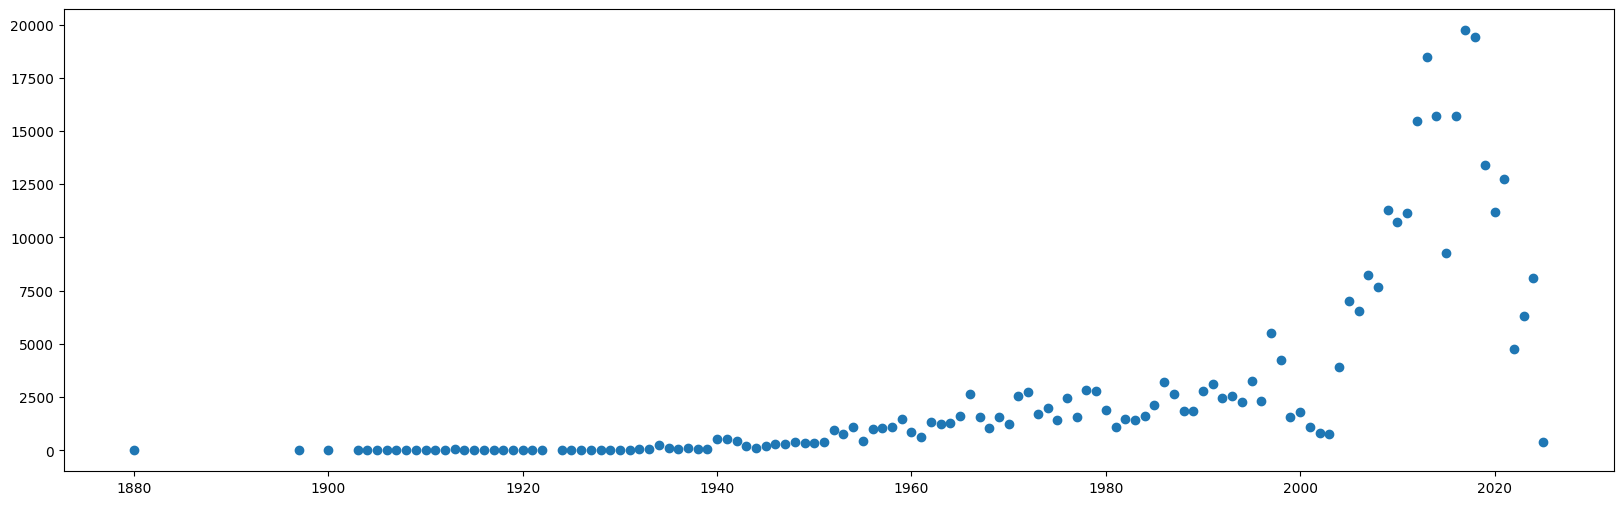

In [114]:
fig, ax = plt.subplots(figsize = (20, 6))
ax.scatter(y = df_merged.groupby('year').count().species, x = sorted(pd.unique(df_merged.year)))

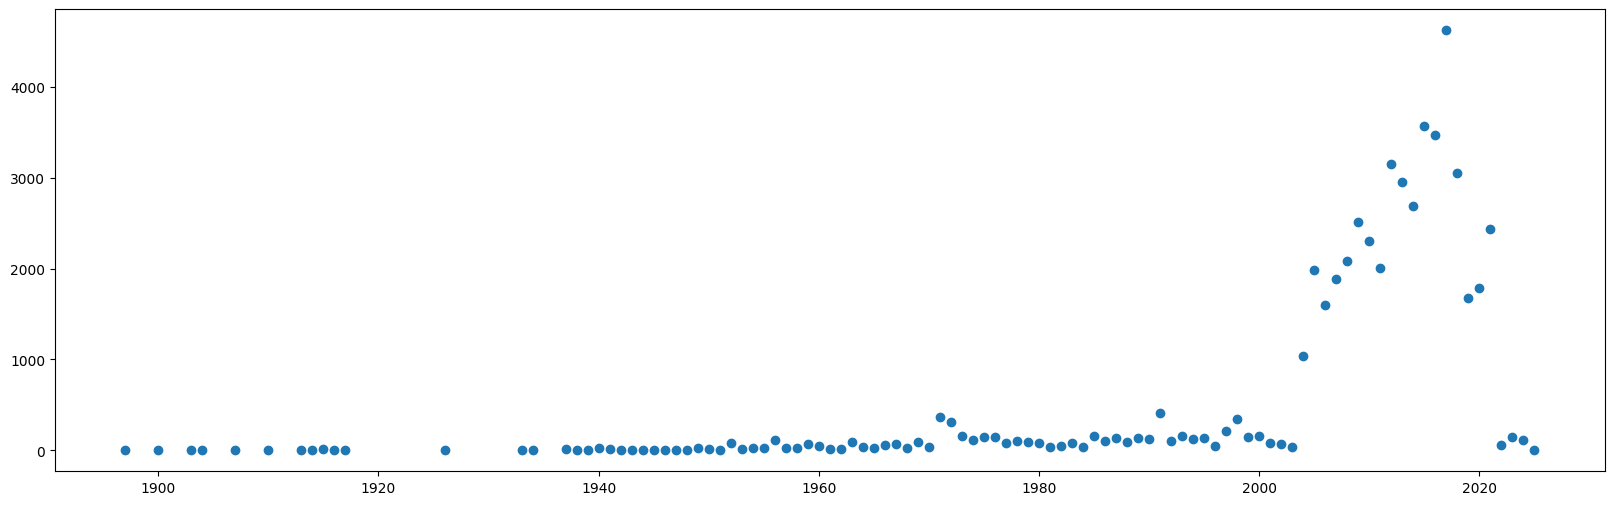

In [119]:
df_merged_50 = df_merged[df_merged.species.isin(set(target_species50.species))].reset_index(drop = True)
fig, ax = plt.subplots(figsize = (20, 6))
ax.scatter(y = df_merged_50.groupby('year').count().species, x = sorted(pd.unique(df_merged_50.year)))

In [117]:
df_merged

,species,year,month,day,decimalLatitude,decimalLongitude
0,Synuchus melantho,2004,8,30,137.170000,35.220000
1,Synuchus melantho,2004,8,30,137.170000,35.220000
2,Synuchus melantho,2004,8,30,137.170000,35.220000
3,Synuchus melantho,2004,10,26,137.170000,35.220000
4,Synuchus nitidus,2004,10,26,137.170000,35.220000
...,...,...,...,...,...,...
339147,Prismognathus dauricus,1984,7,26,34.133333,129.216667
339148,Serrognathus costatus,1985,9,6,28.315795,129.423161
339149,Prismognathus dauricus,1984,7,26,34.133333,129.216667
339150,Prismognathus angularis,1974,8,24,34.676936,135.866691


In [ ]:
Phelotrupes auratus
Phelotrupes laevistriatus

In [302]:
len(df_gbif_family[(df_gbif_family.species == 'Phelotrupes laevistriatus') & (~pd.isna(df_gbif_family.elevation))])


3795

(array([2702.,   34.,  819.,   11.,    9.,   11.,  185.,    7.,    0.,
          17.]),
 array([   0. ,  142.5,  285. ,  427.5,  570. ,  712.5,  855. ,  997.5,
        1140. , 1282.5, 1425. ]),
 <BarContainer object of 10 artists>)

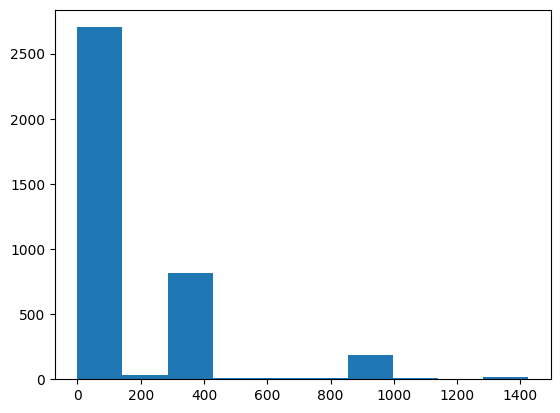

In [299]:
np.nanmean(df_gbif_family[df_gbif_family.species == 'Phelotrupes laevistriatus'].elevation)
plt.hist(df_gbif_family[df_gbif_family.species == 'Phelotrupes laevistriatus'].elevation, bins = 10)

In [303]:
len(df_gbif_family[(df_gbif_family.species == 'Phelotrupes auratus') & (~pd.isna(df_gbif_family.elevation))])


53

(array([ 8.,  1., 10., 17.,  2.,  7.,  1.,  0.,  0.,  7.]),
 array([140. , 208.5, 277. , 345.5, 414. , 482.5, 551. , 619.5, 688. ,
        756.5, 825. ]),
 <BarContainer object of 10 artists>)

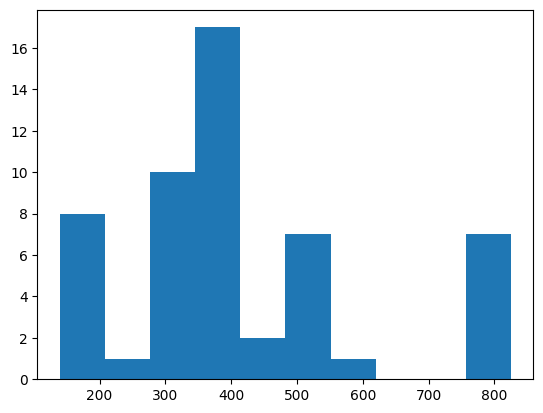

In [296]:
np.nanmean(df_gbif_family[df_gbif_family.species == 'Phelotrupes auratus'].elevation)
plt.hist(df_gbif_family[df_gbif_family.species == 'Phelotrupes auratus'].elevation)